Data_Cleaning

In [1]:
import pandas as pd

credit_df = pd.read_csv("../data/raw/creditcard.csv")


In [2]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
credit_df.shape

(284807, 31)

In [4]:
credit_df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
credit_df.duplicated().sum()

np.int64(1081)

In [6]:
credit_df = credit_df.drop_duplicates()

Exploratory Data Analysis

UNIVARIATE ANALYSIS

Class Distribution

In [15]:

class_counts = credit_df["Class"].value_counts()

print(class_counts)
print("\nFraud Rate (%):")
print(credit_df["Class"].value_counts(normalize=True) * 100)

Class
0    283253
1       473
Name: count, dtype: int64

Fraud Rate (%):
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


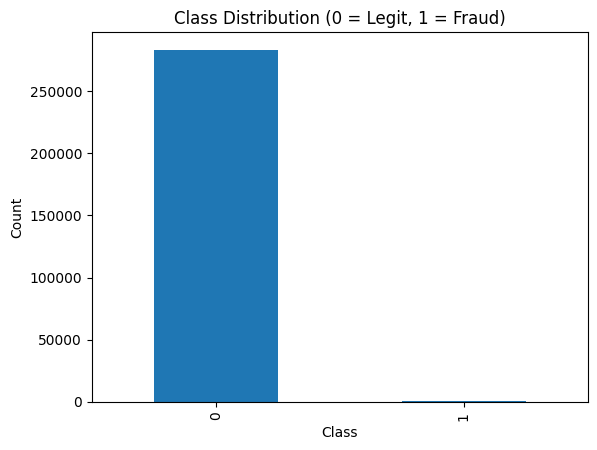

In [ ]:
import matplotlib.pyplot as plt


class_counts.plot(kind="bar")
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Transaction Amount Distribution

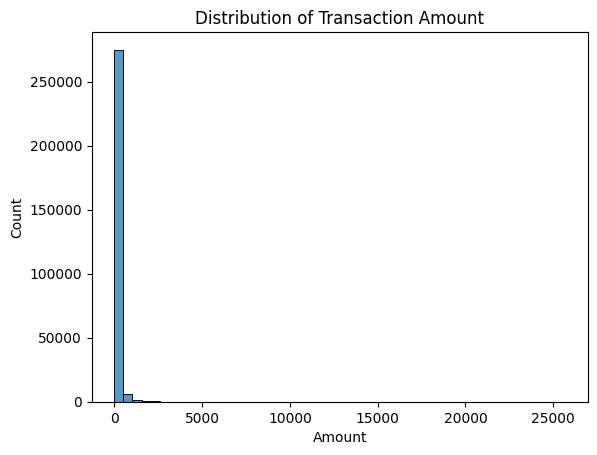

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(credit_df["Amount"], bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()

Time Distribution

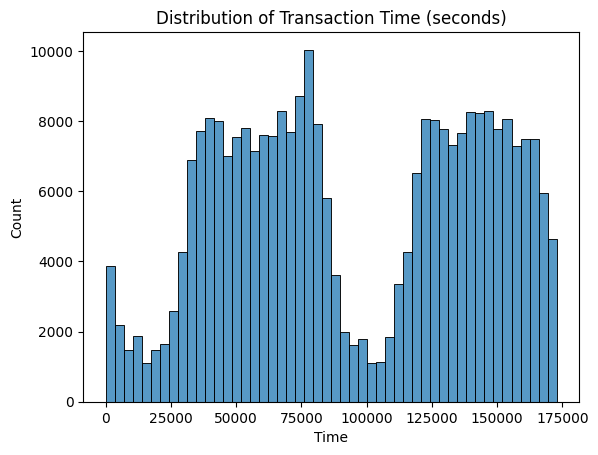

In [19]:
sns.histplot(credit_df["Time"], bins=50)
plt.title("Distribution of Transaction Time (seconds)")
plt.show()

PCA Features (V1–V28) Distribution

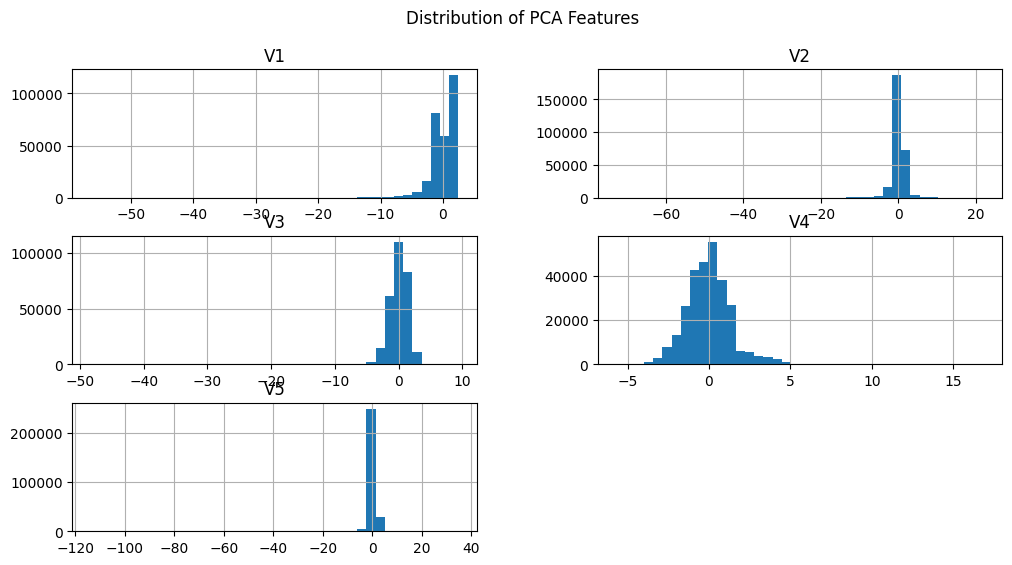

In [20]:
features = ["V1", "V2", "V3", "V4", "V5"]

credit_df[features].hist(bins=40, figsize=(12,6))
plt.suptitle("Distribution of PCA Features")
plt.show()

Fraud vs Non-Fraud Distribution

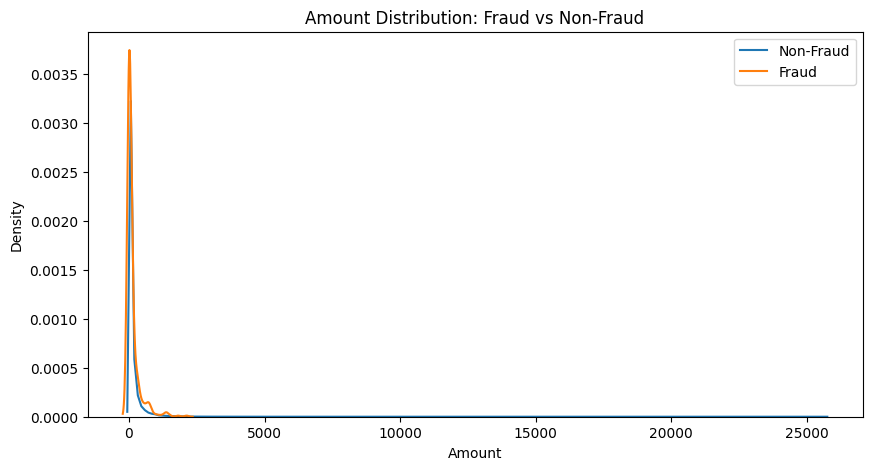

In [21]:
fraud = credit_df[credit_df["Class"] == 1]
non_fraud = credit_df[credit_df["Class"] == 0]

plt.figure(figsize=(10,5))

sns.kdeplot(non_fraud["Amount"], label="Non-Fraud")
sns.kdeplot(fraud["Amount"], label="Fraud")

plt.title("Amount Distribution: Fraud vs Non-Fraud")
plt.legend()
plt.show()

Bivariate Analysis

Amount vs Class

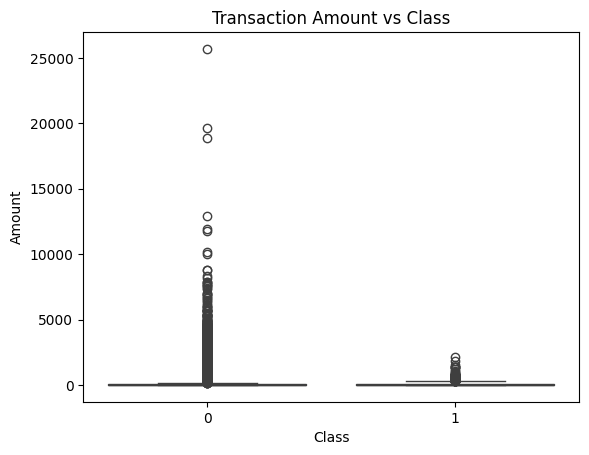

In [22]:
sns.boxplot(x="Class", y="Amount", data=credit_df)
plt.title("Transaction Amount vs Class")
plt.show()

Time vs Class

In [ ]:
sns.boxplot(x="Class", y="Time", data=df)
plt.title("Transaction Time vs Class")
plt.show()

Correlation with Class

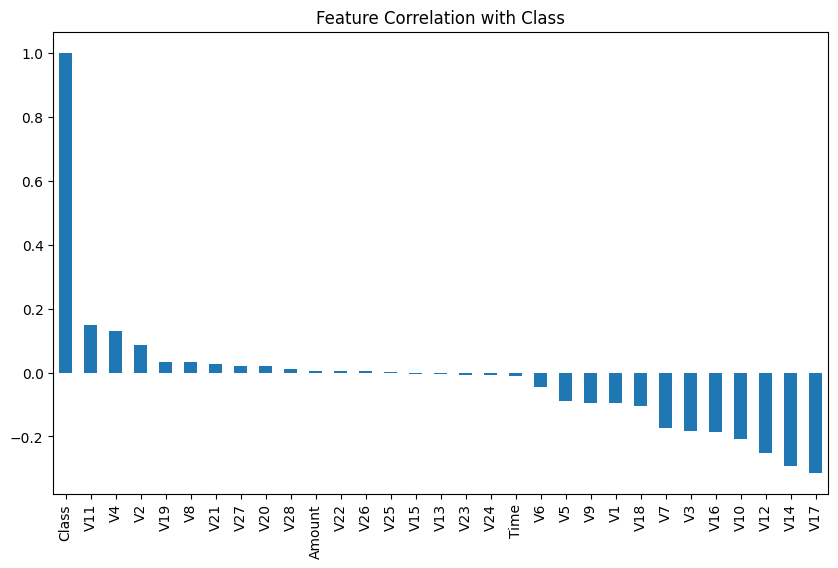

In [23]:
corr = credit_df.corr()

plt.figure(figsize=(10,6))
corr["Class"].sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Correlation with Class")
plt.show()

Heatmap

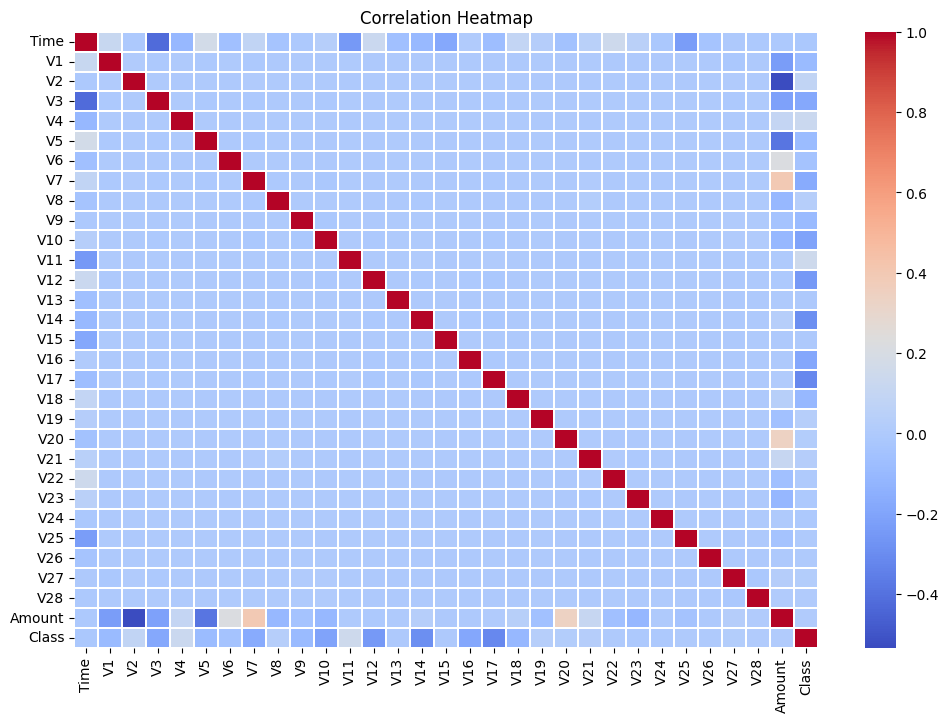

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(credit_df.corr(), cmap="coolwarm", linewidths=0.3)
plt.title("Correlation Heatmap")
plt.show()

Fraud Pattern Deep Dive

Compare Mean Feature Values

In [25]:
credit_df.groupby("Class").mean().T.head(15)

Class,0,1
Time,94835.058093,80450.513742
V1,0.013439,-4.498280
V2,-0.009829,3.405965
V3,0.012853,-6.729599
V4,-0.010440,4.472591
V5,0.006769,-2.957197
V6,0.001251,-1.432518
V7,0.010447,-5.175912
V8,-0.002448,0.953255
V9,0.002613,-2.522124


Strong Fraud Indicators

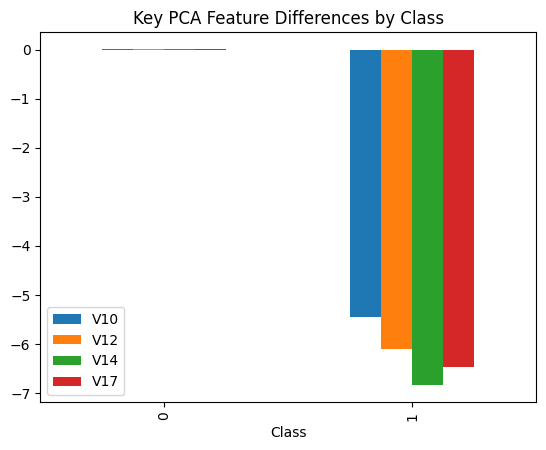

In [26]:
important_features = ["V10", "V12", "V14", "V17"]

credit_df.groupby("Class")[important_features].mean().plot(kind="bar")
plt.title("Key PCA Feature Differences by Class")
plt.show()

Class Imbalance

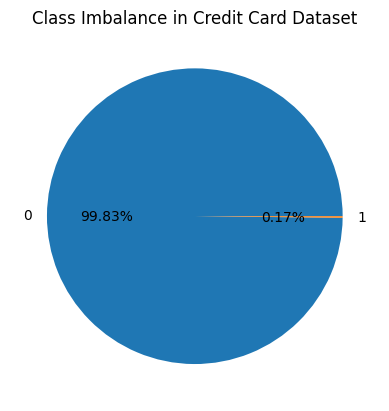

In [29]:
imbalance = credit_df["Class"].value_counts()

imbalance.plot(kind="pie", autopct="%1.2f%%")
plt.title("Class Imbalance in Credit Card Dataset")
plt.ylabel("")
plt.show()

geolocation integration

Load Data